In [530]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [531]:
df = pd.read_csv("../data/diabetes.csv")

## Data Understanding

In [532]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [533]:
df.shape

(768, 9)

In [534]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00
Glucose,768.0,120.894531,31.972618,0.000,99.00000,117.0000,140.25000,199.00
BloodPressure,768.0,69.105469,19.355807,0.000,62.00000,72.0000,80.00000,122.00
SkinThickness,768.0,20.536458,15.952218,0.000,0.00000,23.0000,32.00000,99.00
Insulin,768.0,79.799479,115.244002,0.000,0.00000,30.5000,127.25000,846.00
BMI,768.0,31.992578,7.884160,0.000,27.30000,32.0000,36.60000,67.10
DiabetesPedigreeFunction,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
Age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00
Outcome,768.0,0.348958,0.476951,0.000,0.00000,0.0000,1.00000,1.00


In [535]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [536]:
df.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

In [537]:
df.dtypes

Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object

### Handling Missing Data

In [538]:
df['Insulin'].value_counts()

Insulin
0      374
105     11
130      9
140      9
120      8
      ... 
73       1
171      1
255      1
52       1
112      1
Name: count, Length: 186, dtype: int64

- Il fatto che l'insulina sia 0 è impossibile a livello medico, questo significa che il dato è stato insirito come 0 anche se mancante

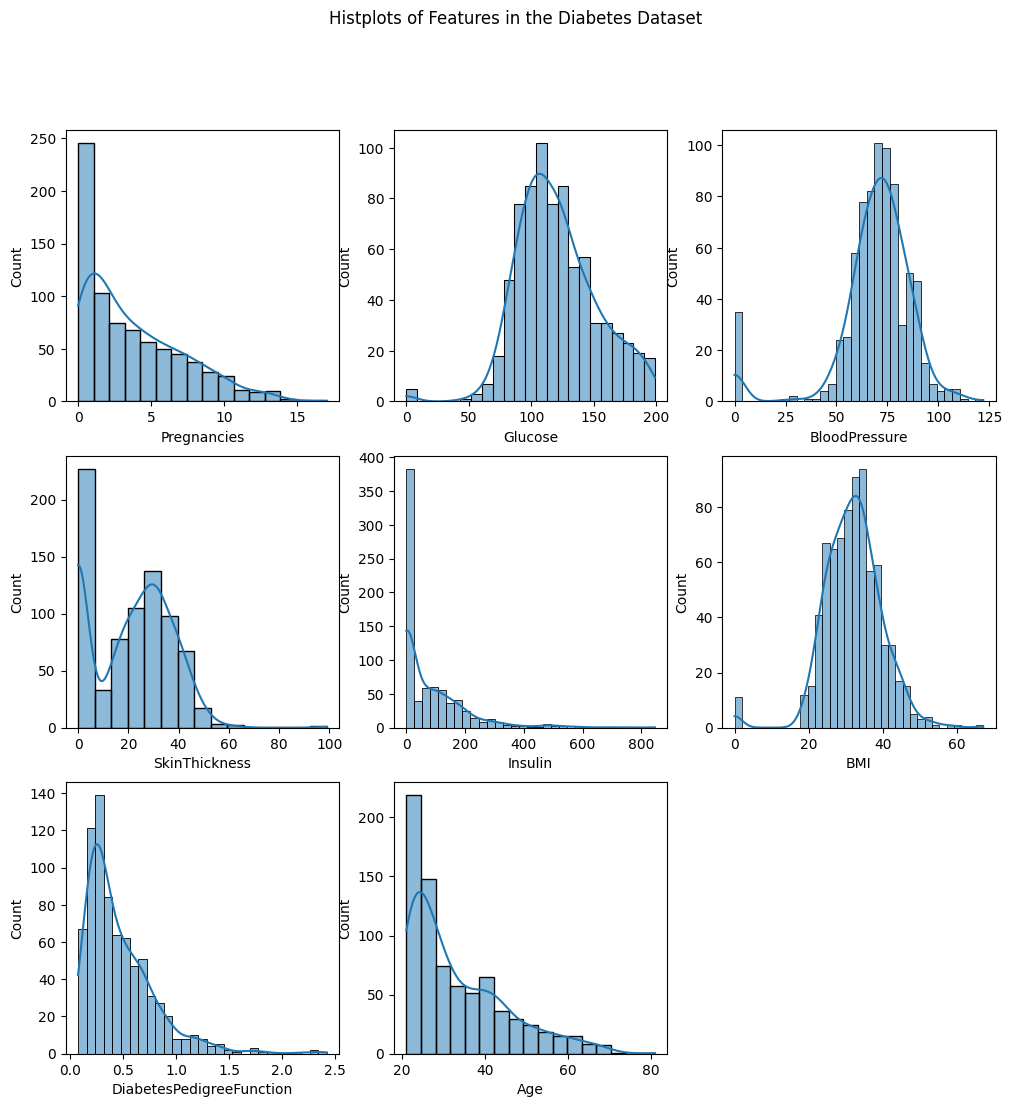

In [539]:
plt.figure(figsize=(12,12))

for i, col in enumerate(df.columns):
    if col == 'Outcome':
        continue
    plt.subplot(3, 3, i+1)
    sns.histplot(x=col, data=df, kde=True)

plt.suptitle('Histplots of Features in the Diabetes Dataset')
plt.show()

Dalle distribuzioni si vede che le seguenti colonne hanno dei valori 0 che dovrebbero essere nulli

In [540]:
diabetes_data_copy = df.copy(deep = True)
diabetes_data_copy[['Glucose','BloodPressure','SkinThickness','Insulin','BMI']] = diabetes_data_copy[['Glucose','BloodPressure','SkinThickness','Insulin','BMI']].replace(0,np.nan)

## showing the count of Nans
print(diabetes_data_copy.isnull().sum())

Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64


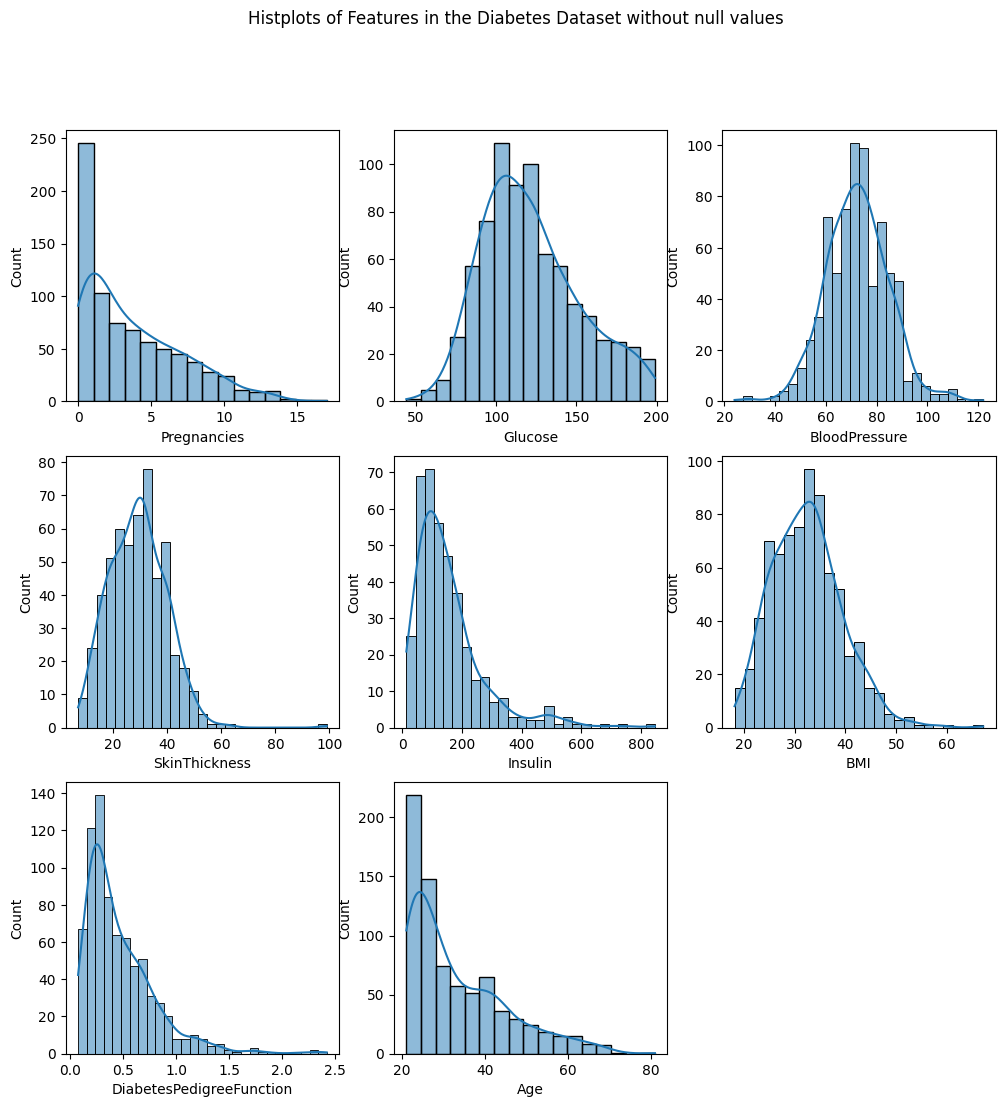

In [541]:
plt.figure(figsize=(12,12))

for i, col in enumerate(df.columns):
    if col == 'Outcome':
        continue
    plt.subplot(3, 3, i+1)
    sns.histplot(x=col, data=diabetes_data_copy, kde=True)

plt.suptitle('Histplots of Features in the Diabetes Dataset without null values')
plt.show()

In [542]:
fill_values = {
    'Glucose': diabetes_data_copy['Glucose'].mean(),
    'BloodPressure': diabetes_data_copy['BloodPressure'].mean(),
    'SkinThickness': diabetes_data_copy['SkinThickness'].median(),
    'Insulin': diabetes_data_copy['Insulin'].median(),
    'BMI': diabetes_data_copy['BMI'].median()
}

**Rimpiazziamo i valori nulli con le medie e mediane delle distribuzioni**

In [543]:
# for col, value in fill_values.items():
#     diabetes_data_copy[col] = diabetes_data_copy[col].fillna(value)

**Escludiamo i valori nulli**

In [544]:
diabetes_data_copy.dropna(inplace=True)
diabetes_data_copy.shape

(392, 9)

In [545]:
df = diabetes_data_copy

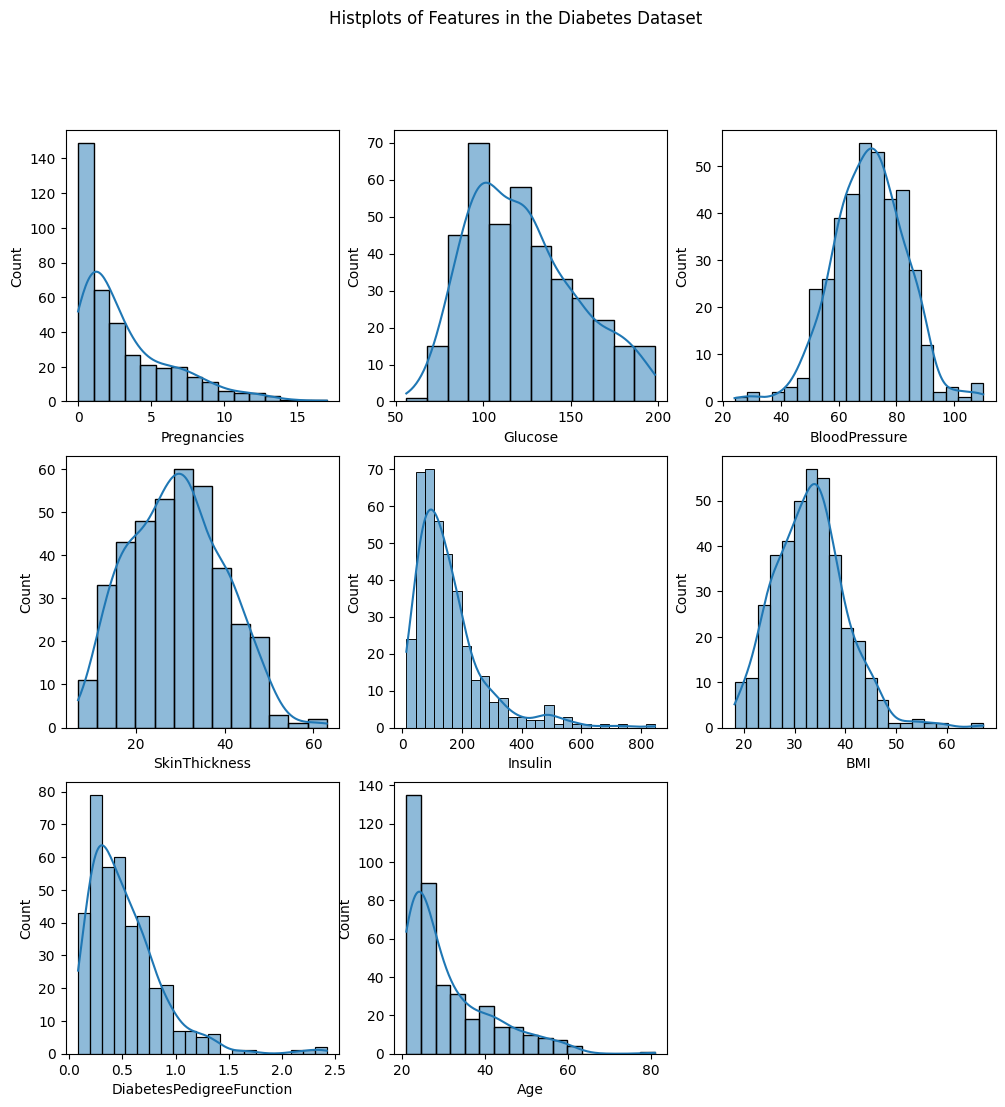

In [546]:
plt.figure(figsize=(12,12))

for i, col in enumerate(df.columns):
    if col == 'Outcome':
        continue
    plt.subplot(3, 3, i+1)
    sns.histplot(x=col, data=df, kde=True)

plt.suptitle('Histplots of Features in the Diabetes Dataset')
plt.show()

## Data Visualization

**Observing Outcomes**

In [547]:
df['Outcome'].value_counts()

Outcome
0    262
1    130
Name: count, dtype: int64

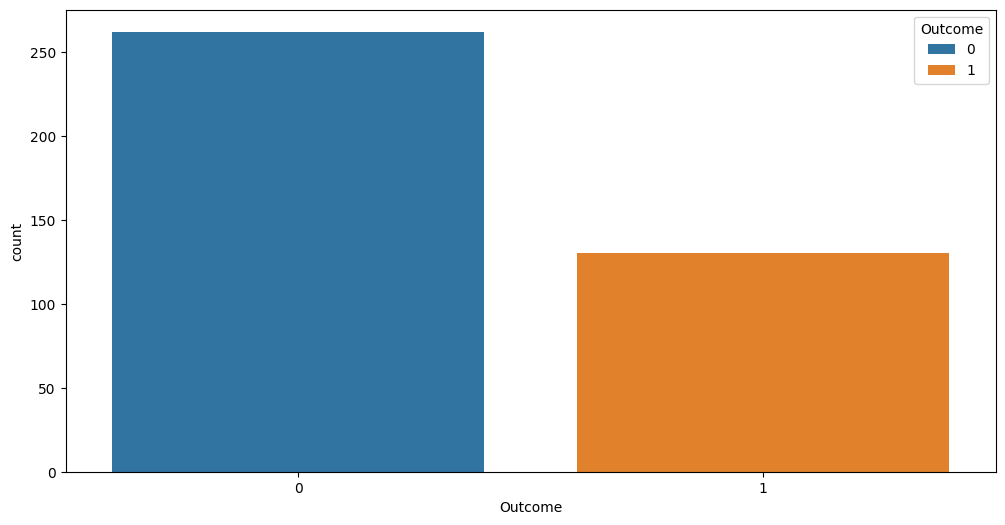

In [548]:
plt.figure(figsize=(12, 6))
sns.countplot(x='Outcome', hue='Outcome', data=df)
plt.show()

**Observing Outliers**

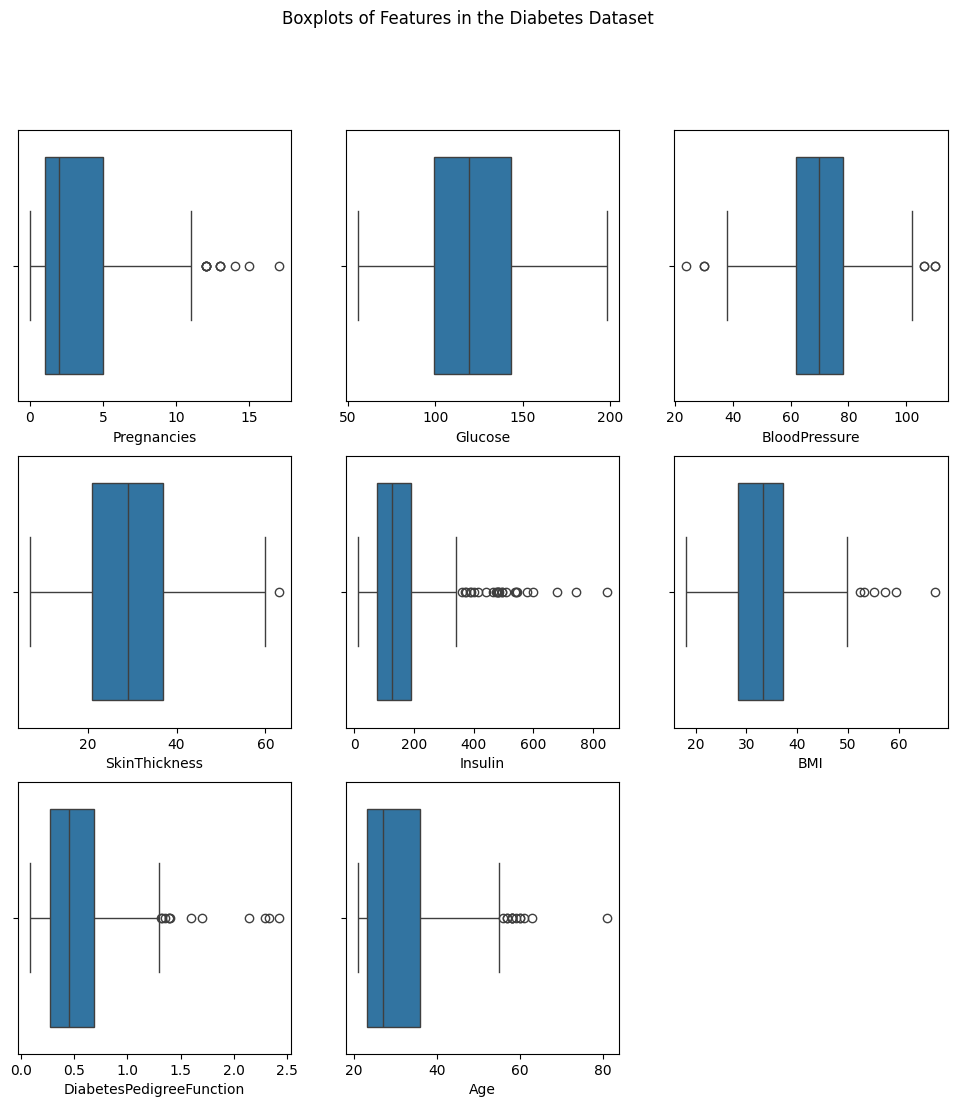

In [549]:
plt.figure(figsize=(12,12))

for i, col in enumerate(df.columns):
    if col == 'Outcome':
        continue
    plt.subplot(3, 3, i+1)
    sns.boxplot(x=col, data=df)
plt.suptitle('Boxplots of Features in the Diabetes Dataset')
plt.show()

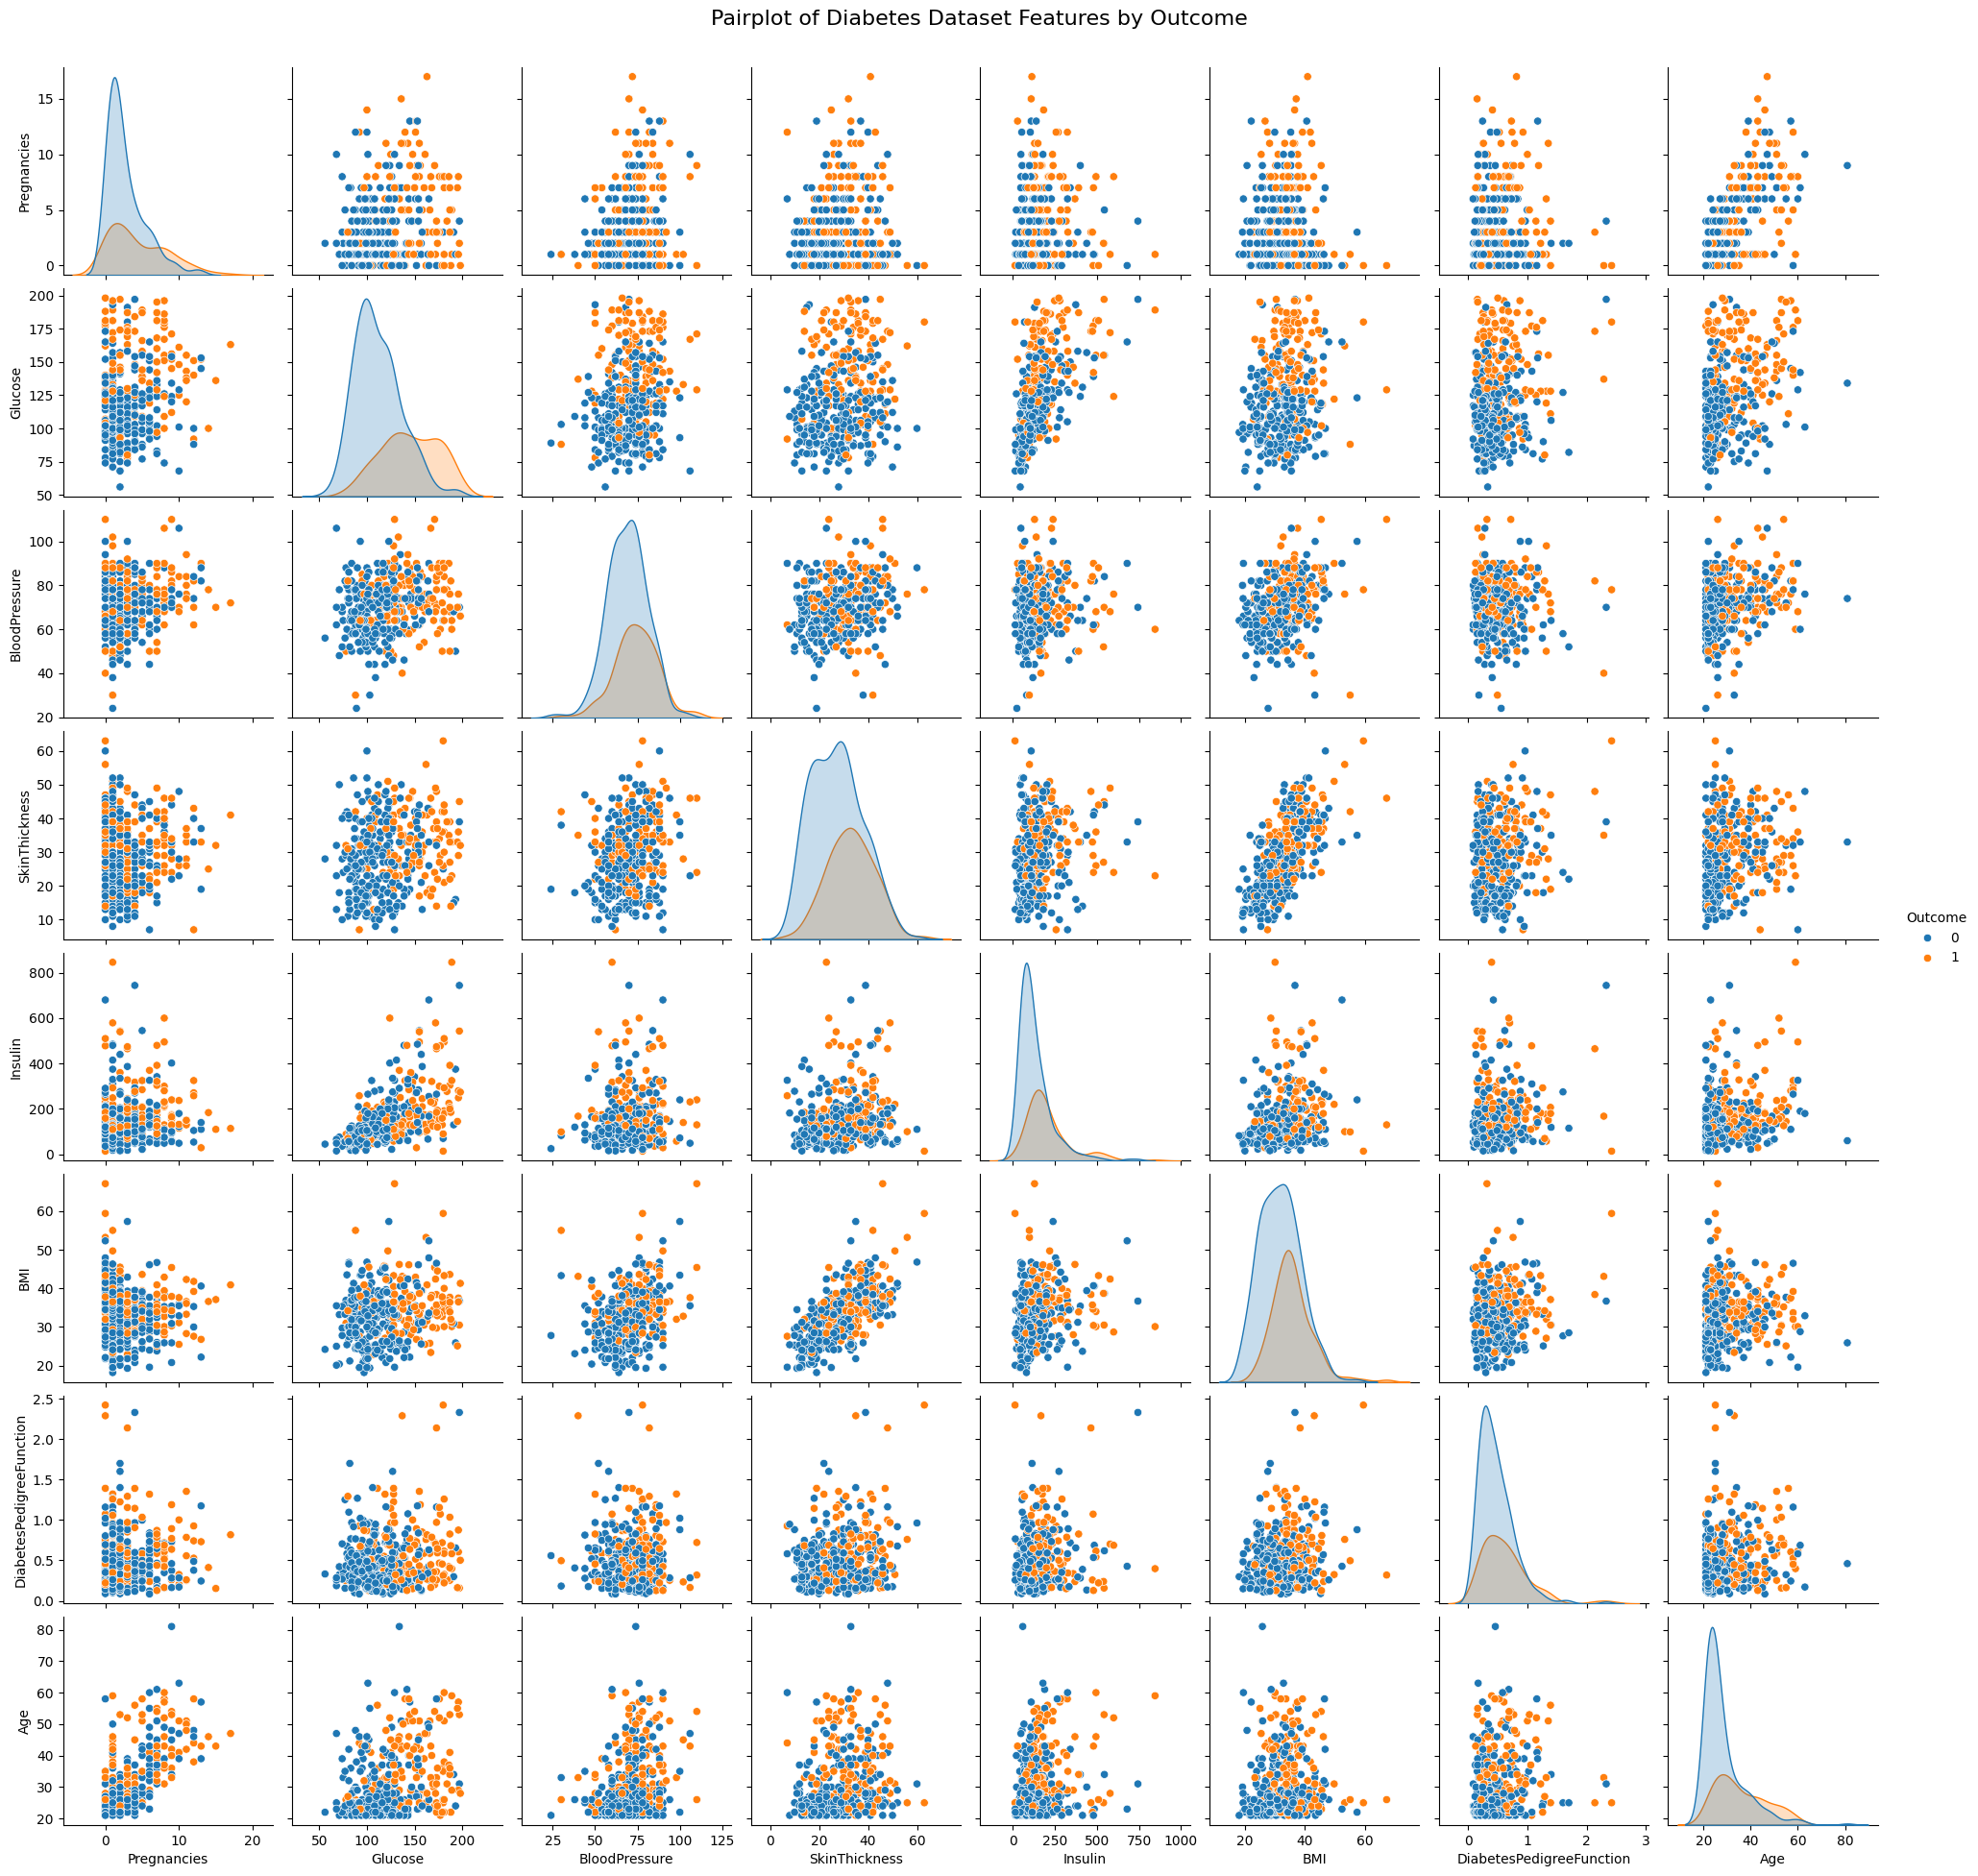

In [550]:
# Create the pairplot and capture the figure
f = sns.pairplot(data=df, hue='Outcome')

f.figure.suptitle('Pairplot of Diabetes Dataset Features by Outcome', fontsize=16)
f.figure.subplots_adjust(top=0.95)
plt.show()

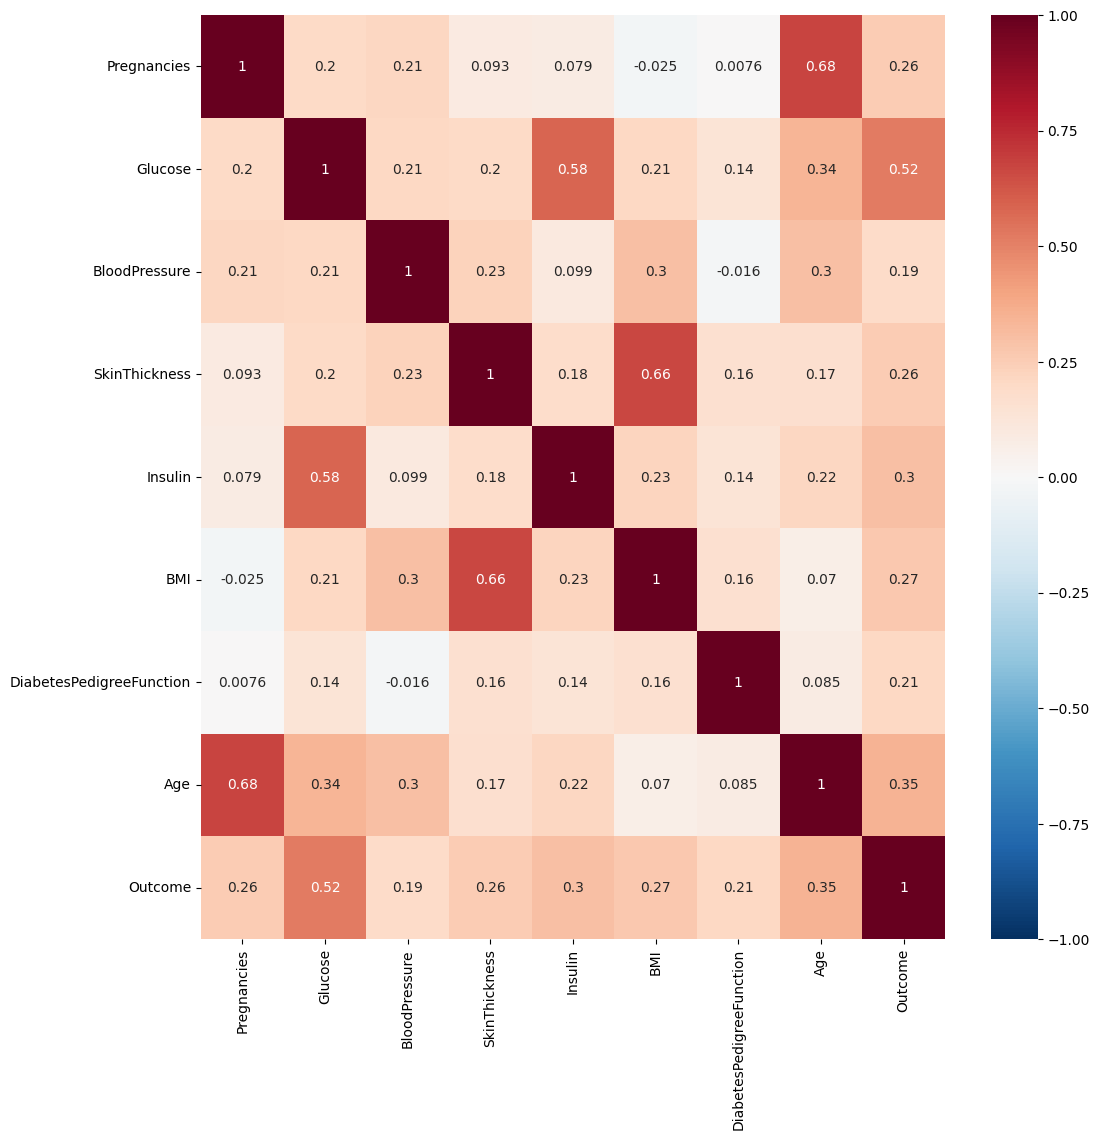

In [551]:
plt.figure(figsize=(12, 12))
sns.heatmap(df.corr(), vmin = -1.0, center=0, cmap='RdBu_r', annot=True)
plt.show()

In [552]:
df.to_csv('../data/diabetes_clean_data.csv', index=False)